Found 81 TIFF(s)

Processing: C66_SC_105_1_10X.nd2
  Shape: (20, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SC_105_1_10X_GFP_DAPI.png
Processing: C66_SC_105_2_10X.nd2
  Shape: (20, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SC_105_2_10X_GFP_DAPI.png
Processing: C66_SC_105_3_10X.nd2
  Shape: (20, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SC_105_3_10X_GFP_DAPI.png
Processing: C66_SC_105_4_10X.nd2
  Shape: (20, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SC_105_4_10X_GFP_DAPI.png
Processing: C66_SNR_5_1_10X.nd2
  Shape: (18, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SNR_5_1_10X_GFP_DAPI.png
Processing: C66_SNR_5_2_10X.nd2
  Shape: (18, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SNR_5_2_10X_GFP_DAPI.png
Processing: C66_SNR_5_3_10X.nd2
  Shape: (18, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SNR_5_3_10X_GFP_DAPI.png
Processing: C66_SNR_5_4_10X.nd2
  Shape: (18, 4, 2048, 2048) | dtype: uint16
  ✔ Saved → C66_SNR_5_4_10X_GFP_DAPI.png
Processing: C68_SC_104_1_10X.n

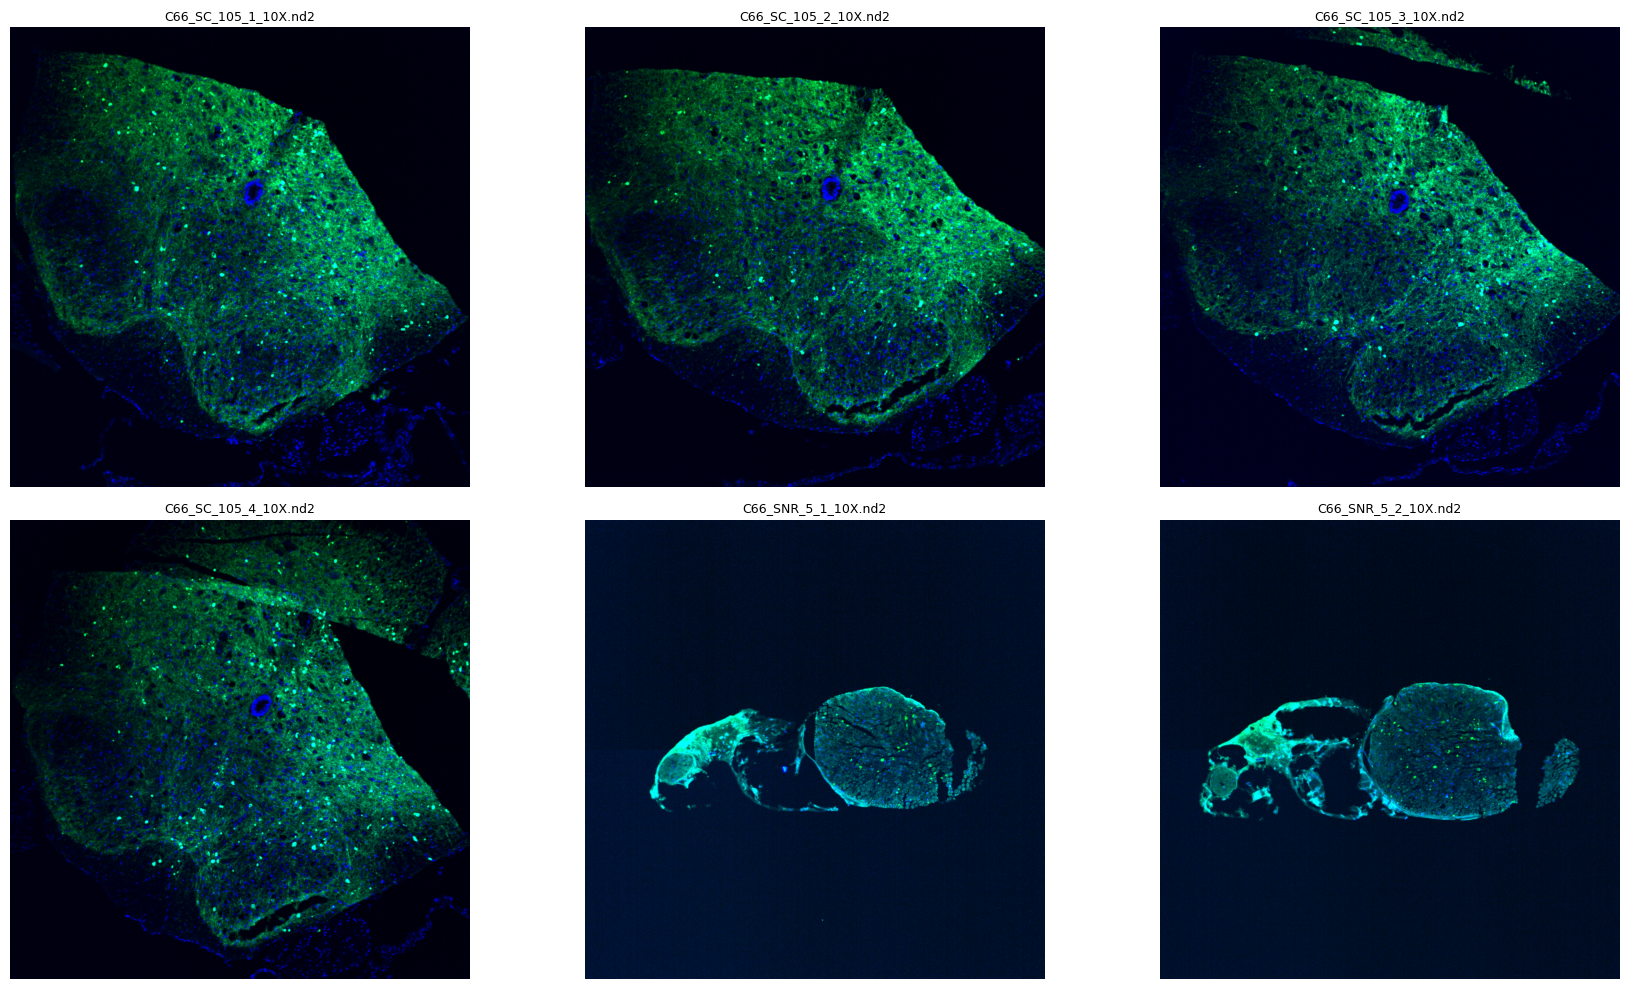

In [2]:
import os
import numpy as np
import tifffile
import nd2
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

# ── Configuration ──────────────────────────────────────────────────────────────
dirpath = r'C:\Users\skaun\Documents\W1\ND2\CD68_CD8\10X'

DAPI_CHANNEL    = 4     # Blue  (1-indexed)
GFP_CHANNEL     = 3     # Green (1-indexed)
OUTPUT_FOLDER   = 'GFP_DAPI'
LOW_PERCENTILE  = 0.5
HIGH_PERCENTILE = 99.5

# ── Helpers ────────────────────────────────────────────────────────────────────
def auto_contrast(arr, low_pct=0.5, high_pct=99.5):
    p_low, p_high = np.percentile(arr, low_pct), np.percentile(arr, high_pct)
    clipped = np.clip(arr, p_low, p_high)
    if p_high > p_low:
        return ((clipped - p_low) / (p_high - p_low) * 255).astype(np.uint8)
    return np.zeros_like(clipped, dtype=np.uint8)

def extract_channel(tiff_array, channel_1indexed):
    ch  = channel_1indexed - 1
    arr = tiff_array.squeeze()
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3:
        return arr[ch] if arr.shape[0] <= 8 else arr[:, :, ch]
    if arr.ndim == 4:                   # (Z, C, Y, X) → max-project Z
        return arr.max(axis=0)[ch]
    raise ValueError(f"Unexpected shape: {arr.shape}")

# ── Main ───────────────────────────────────────────────────────────────────────
input_dir  = Path(dirpath)
output_dir = input_dir / OUTPUT_FOLDER
output_dir.mkdir(parents=True, exist_ok=True)

tiff_files = sorted(input_dir.glob('*.nd2'))
print(f"Found {len(tiff_files)} TIFF(s)\n")

composites = {}

for tiff_path in tiff_files:
    try:
        print(f"Processing: {tiff_path.name}")
        arr = nd2.imread(tiff_path)
        print(f"  Shape: {arr.shape} | dtype: {arr.dtype}")

        blue_u8  = auto_contrast(extract_channel(arr, DAPI_CHANNEL))
        green_u8 = auto_contrast(extract_channel(arr, GFP_CHANNEL))

        h, w     = blue_u8.shape
        composite = np.zeros((h, w, 3), dtype=np.uint8)
        composite[:, :, 1] = green_u8   # G
        composite[:, :, 2] = blue_u8    # B

        out_path = output_dir / f"{tiff_path.stem}_GFP_DAPI.png"
        Image.fromarray(composite).save(out_path)
        composites[tiff_path.name] = composite
        print(f"  ✔ Saved → {out_path.name}")

    except Exception as e:
        print(f"  ✘ ERROR: {e}")

print(f"\nDone! {len(composites)} composite(s) saved to '{OUTPUT_FOLDER}'.")

# ── Preview (optional) ─────────────────────────────────────────────────────────
preview = list(composites.items())[:6]
cols = min(len(preview), 3)
rows = (len(preview) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
for ax, (name, img) in zip(np.array(axes).flatten(), preview):
    ax.imshow(img); ax.set_title(name, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()